In [13]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
results = np.load("MC_simulation_results.npy", allow_pickle=True).item()

DKRL
[0.003218542093985199, 0.0020581045557255683, 0.0012987479130286657, 0.00032234063791420546, 0.00016799936876098345, 3.8988012425434806e-05, 2.3438776998175468e-05]
[0.0031959248400486185, 0.003227089562375997, 0.0034085335140849413, 0.0036005689405343337, 0.003575382557602408, 0.0036686874971212633, 0.0034882318741510875]
[0.00030189337546281017, 8.378873995756598e-05, 5.291999607519331e-05, 1.222935226697159e-05, 1.0667182794773136e-05, 3.945194022455155e-06, 4.013066534700159e-06]
[0.0005464333012072749, 0.000543403772366239, 0.0005855365477989406, 0.0005316988266449973, 0.00046283625644011686, 0.00045377207544734056, 0.0005814918663854125]
KZ
[0.0019836534465851184, 0.001243752468164916, 0.0009495785153732048, 0.0003556497722697844, 0.00022977656720494312, 6.81431535445426e-05, 2.9352277449639197e-05]
[0.003570644662132914, 0.004260421492879354, 0.004598365598285993, 0.005406874858029082, 0.005899931590312999, 0.006358545191111589, 0.006366377271019736]
[0.0002131154091192801,

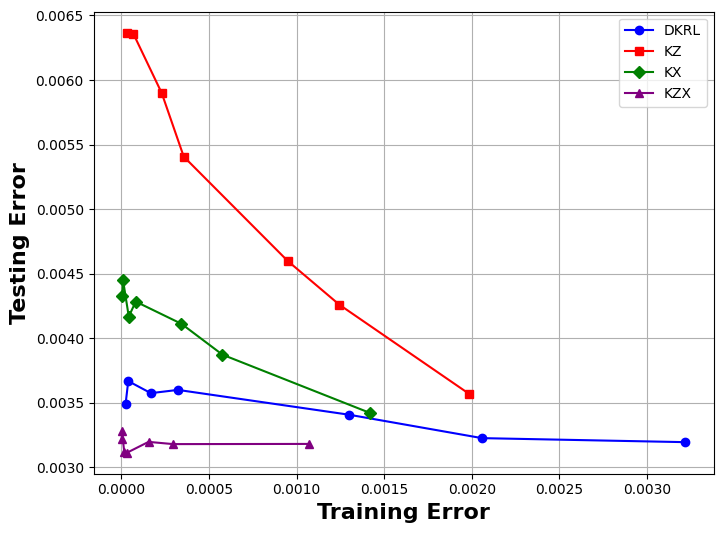

In [24]:
# Define methods, colors, and markers
methods = ["DKRL", "KZ", "KX", "KZX"]
colors = {"DKRL": "blue", "KZ": "red", "KX": "green", "KZX": "purple"}
markers = {"DKRL": "o", "KZ": "s", "KX": "D", "KZX": "^"}

# Initialize plot
plt.figure(figsize=(8, 6))

# Iterate through methods and collect training vs testing error under different pt_levels
for method in methods:
    train_errs = []
    test_errs = []
    train_stds = []
    test_stds = []
    pt_levels = []

    for pt in results.keys():
        train_err_mean = np.mean(results[pt][method]["train_err"])
        test_err_mean = np.mean(results[pt][method]["test_err"])
        train_err_std = np.std(results[pt][method]["train_err"])
        test_err_std = np.std(results[pt][method]["test_err"])
        train_errs.append(train_err_mean)
        test_errs.append(test_err_mean)
        train_stds.append(train_err_std)
        test_stds.append(test_err_std)
        pt_levels.append(pt)

    print(method)
    print(train_errs)
    print(test_errs)
    print(train_stds)
    print(test_stds)    

    # Plot each method's training vs testing error with different markers
    plt.plot(train_errs, test_errs, marker=markers[method], color=colors[method], linestyle='-', label=method)

    # Annotate points with their pt_level values
    # for i, txt in enumerate(pt_levels):
    #     plt.annotate(f"{txt:.1e}", (train_errs[i], test_errs[i]), fontsize=10, color=colors[method])

# Labels, legend, and grid
plt.xlabel("Training Error", fontsize=16, fontweight='bold')
plt.ylabel("Testing Error", fontsize=16, fontweight='bold')
# plt.title("Training Error vs Testing Error for Different Methods")
plt.legend()
plt.grid(True)

# save 
plt.savefig("train-test.png")

# Show the plot
plt.show()

<Figure size 640x480 with 0 Axes>